In [19]:
import numpy as np
import pandas as pd
import networkx as nx
from sklearn.linear_model import LogisticRegression
from scipy.special import expit
import itertools
import matplotlib.pyplot as plt

from methods.constants import NetworkSettings, DataGenerationSettings
from data_generation.data_simulator import IndividualDataSimulator

In [5]:
class LogisticGraphGenerator:
    def __init__(self, beta: np.ndarray):
        """
        Логистическая регрессия для генерации сети на основе ковариат.
        :param beta: Коэффициенты логистической регрессии для влияния ковариат на вероятность связи.
        """
        self.beta = beta

    def generate_network(self, covariates: np.ndarray, threshold: float = 0.5) -> np.ndarray:
        """
        Генерирует сеть на основе ковариат с использованием логистической модели.
        :param covariates: Матрица (N, d) ковариат узлов.
        :param threshold: Порог вероятности для установления связи (по умолчанию 0.5).
        :return: Матрица смежности (N, N).
        """
        n_nodes = covariates.shape[0]
        adjacency_matrix = np.zeros((n_nodes, n_nodes))

        for i, j in itertools.combinations(range(n_nodes), 2):
            feature_diff = np.abs(covariates[i] - covariates[j])  # Разница ковариат между узлами
            prob = expit(np.dot(feature_diff, self.beta))  # Вероятность связи
            if prob > threshold:
                adjacency_matrix[i, j] = adjacency_matrix[j, i] = 1  # Добавляем связь

        return adjacency_matrix

In [7]:
# initialization 

network_settings = NetworkSettings()
dgp_settings = DataGenerationSettings()

In [11]:
individual_data_simulator = IndividualDataSimulator(
    n_nodes=network_settings.n_nodes,
    n_features=dgp_settings.n_features,
    error_mean=dgp_settings.error_mean,
    error_std=dgp_settings.error_std,
    beta_mean=dgp_settings.beta_mean,
    beta_std=dgp_settings.beta_std,
    share_treatment=dgp_settings.share_treatment,
    group_assignment_type=dgp_settings.assignment_types[0]
)

In [25]:
covariates = individual_data_simulator.generate_random_covariates()
beta = np.array([3, 2]) # random, just to check 
logit_model = LogisticGraphGenerator(beta=beta)
logit_network = logit_model.generate_network(covariates, threshold=0.999)

In [27]:
G = nx.from_numpy_array(logit_network)
avg_degree = np.mean([deg for _, deg in G.degree()])
print(f"Среднее число связей на узел: {avg_degree:.2f}")


Среднее число связей на узел: 31.60


In [29]:
edges = np.array(G.edges)
diffs = np.abs(covariates[edges[:, 0]] - covariates[edges[:, 1]])  # Разница ковариат у соединенных узлов
mean_diff = diffs.mean(axis=0)  # Средняя разница по каждой ковариате

print(f"Средняя разница ковариат между связанными узлами: {mean_diff}")


Средняя разница ковариат между связанными узлами: [2.06102706 1.59696131]


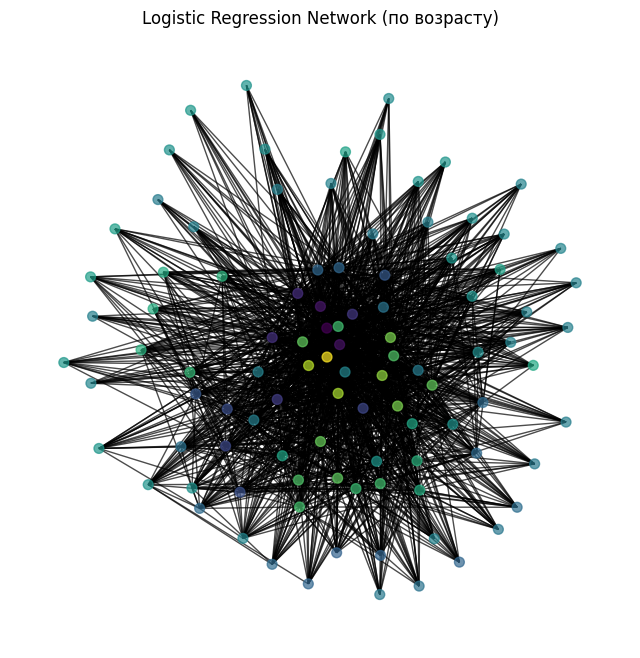

In [28]:
plt.figure(figsize=(8, 8))
plt.title("Logistic Regression Network (по возрасту)")
node_colors = covariates[:, 0]  
nx.draw(G, node_size=50, alpha=0.7, cmap=plt.cm.viridis, node_color=node_colors)
plt.show()

In [31]:
from sklearn.cluster import KMeans

class StochasticBlockModel:
    def __init__(self, n_blocks: int, inter_block_probs: np.ndarray):
        """
        SBM, в которой блоки определяются по ковариатам.
        :param n_blocks: Количество блоков (групп).
        :param inter_block_probs: Матрица (n_blocks, n_blocks) вероятностей связей между блоками.
        """
        self.n_blocks = n_blocks
        self.inter_block_probs = inter_block_probs

    def assign_blocks(self, covariates: np.ndarray):
        """
        Определяет блоки на основе кластеризации узлов по ковариатам.
        :param covariates: Матрица (n_nodes, n_features).
        :return: Вектор присвоения блоков для узлов.
        """
        kmeans = KMeans(n_clusters=self.n_blocks, random_state=42, n_init=10)
        return kmeans.fit_predict(covariates)

    def generate_network(self, covariates: np.ndarray) -> (np.ndarray, np.ndarray):
        """
        Генерирует сеть согласно SBM на основе кластеризованных ковариат.
        :param covariates: Матрица ковариат узлов.
        :return: Матрица смежности (n_nodes, n_nodes) и распределение узлов по блокам.
        """
        n_nodes = covariates.shape[0]
        block_assignments = self.assign_blocks(covariates)  # Определяем блоки

        adjacency_matrix = np.zeros((n_nodes, n_nodes))

        for i, j in itertools.combinations(range(n_nodes), 2):
            block_i = block_assignments[i]
            block_j = block_assignments[j]
            prob = self.inter_block_probs[block_i, block_j]  # Вероятность связи

            if np.random.rand() < prob:
                adjacency_matrix[i, j] = adjacency_matrix[j, i] = 1  # Добавляем связь

        return adjacency_matrix, block_assignments


In [33]:
n_blocks = 3        #высокая вероятность связи внутри групп, низкая между группами 
inter_block_probs = np.array([[0.8, 0.1, 0.05],  # Межблочные вероятности
                              [0.1, 0.7, 0.1],
                              [0.05, 0.1, 0.6]])
sbm_model = StochasticBlockModelWithCovariates(n_blocks, inter_block_probs)
adj_matrix, block_assignments = sbm_model.generate_network(covariates)

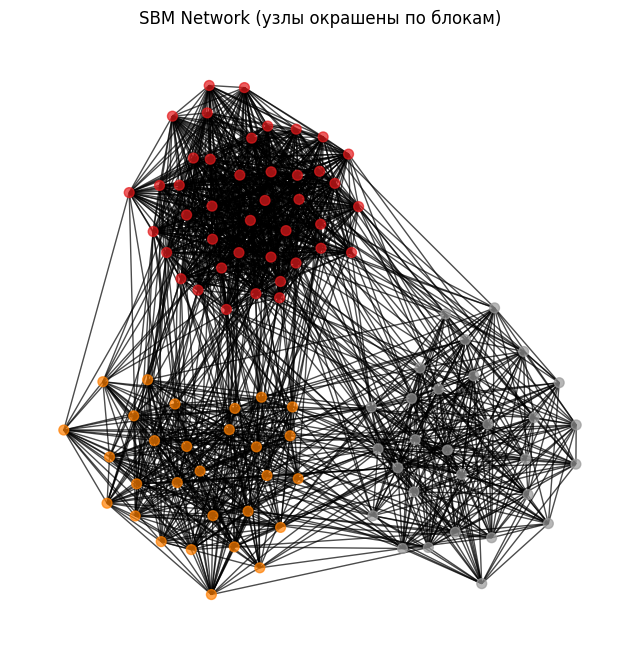

In [34]:
G = nx.from_numpy_array(adj_matrix)
plt.figure(figsize=(8, 8))
plt.title("SBM Network (узлы окрашены по блокам)")
nx.draw(G, node_color=block_assignments, node_size=50, alpha=0.7, cmap=plt.cm.Set1)
plt.show()